# EA FC Player Retention & Onboarding Analytics Dashboard

### Product Analytics Portfolio Project

**Objective:** Identify early-player engagement and retention opportunities and evaluate a proposed Week 1 Player Journey.

**Primary KPI:** Day-7 Retention

**Data:** Synthetic player data created for portfolio demonstration.

> This project does not use proprietary EA or EA SPORTS FC data.

# Executive Insights

### 1. Retention Opportunity
D7 retention is approximately 32.68% across the synthetic player population.

### 2. Largest Player Segment Opportunity
Moderate Engagement players represent approximately 45% of the player base but have only 27.16% D7 retention.

### 3. Product Opportunity
Moderate Engagement players show a 17.10 percentage-point D7 retention gap compared with High Engagement players.

### 4. Experiment Result
The proposed Week 1 Player Journey increased D7 retention from 27.52% to 30.68% in the synthetic A/B experiment.

### 5. Experiment Decision
The observed +3.16 percentage-point lift was statistically significant (p = 0.0021), with a 95% confidence interval of +1.15 to +5.17 percentage points.

### 6. Product Recommendation
Proceed with a gradual rollout, prioritizing Low-to-Moderate Engagement new players while monitoring retention quality and product guardrails.

## Product Loop

**Play → Progress → Reward → New Goal → Return**

The proposed Week 1 Player Journey is designed to strengthen this early gameplay loop and encourage repeat engagement.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

DATA_PATH = Path("../data/players.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,player_id,acquisition_date,acquisition_channel,age_group,region,platform,tutorial_completed,first_match_played,first_match_result,sessions_week1,matches_week1,avg_session_minutes,progression_level,rewards_claimed,social_feature_used,day_1_retained,day_7_retained,day_30_retained,churned
0,P000001,2026-04-13,Organic,35+,Asia Pacific,PlayStation,True,True,Draw,6,10,77.0,6,2,False,False,False,False,True
1,P000002,2026-06-29,Organic,35+,Europe,Xbox,True,True,Loss,5,7,46.0,6,3,True,True,True,True,True
2,P000003,2026-04-03,TikTok,25-34,Europe,Xbox,False,False,Not Played,9,0,40.7,5,1,True,False,False,False,True
3,P000004,2026-01-15,Paid Ads,25-34,India,PlayStation,True,True,Draw,4,9,48.2,6,2,False,False,False,False,False
4,P000005,2026-04-17,Paid Ads,18-24,Asia Pacific,PlayStation,True,True,Loss,26,55,25.5,39,11,True,True,True,False,False


In [2]:
df.shape

(50000, 19)

## Executive KPI Overview

In [3]:
total_players = len(df)

d7_retention = df["day_7_retained"].mean() * 100

d1_retention = df["day_1_retained"].mean() * 100

d30_retention = df["day_30_retained"].mean() * 100

tutorial_completion = df["tutorial_completed"].mean() * 100

first_match_rate = df["first_match_played"].mean() * 100

social_adoption = df["social_feature_used"].mean() * 100

print("Total Players:", f"{total_players:,}")
print("D1 Retention:", f"{d1_retention:.2f}%")
print("D7 Retention:", f"{d7_retention:.2f}%")
print("D30 Retention:", f"{d30_retention:.2f}%")
print("Tutorial Completion:", f"{tutorial_completion:.2f}%")
print("First Match Rate:", f"{first_match_rate:.2f}%")
print("Social Adoption:", f"{social_adoption:.2f}%")

Total Players: 50,000
D1 Retention: 52.66%
D7 Retention: 32.68%
D30 Retention: 20.19%
Tutorial Completion: 75.54%
First Match Rate: 75.09%
Social Adoption: 33.73%


## D7 Retention by Engagement Segment

This view identifies which early-engagement segments have the strongest retention and where the largest product opportunity exists.

In [4]:
df["engagement_segment"] = pd.cut(
    df["sessions_week1"],
    bins=[-1, 3, 10, 20, 35],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

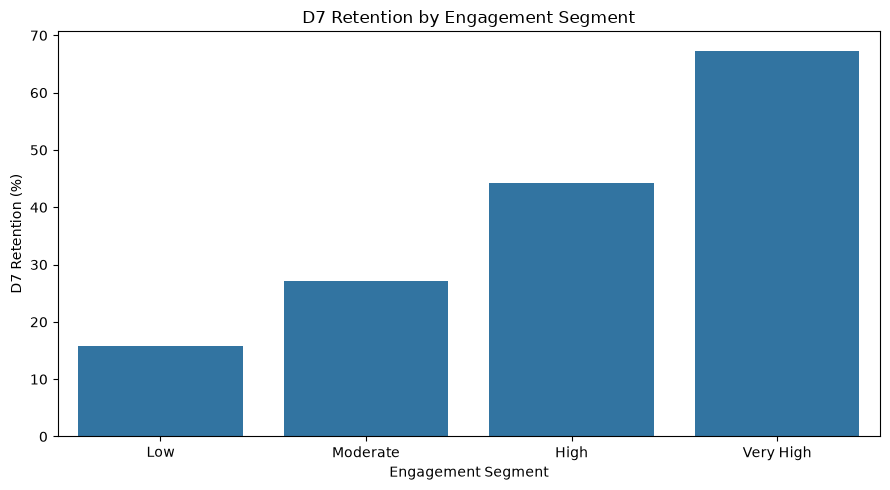

In [5]:
engagement_retention = (
    df.groupby("engagement_segment")["day_7_retained"]
    .mean()
    .mul(100)
    .reindex(["Low", "Moderate", "High", "Very High"])
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=engagement_retention.index,
    y=engagement_retention.values
)

plt.title("D7 Retention by Engagement Segment")
plt.xlabel("Engagement Segment")
plt.ylabel("D7 Retention (%)")

plt.tight_layout()
plt.show()

## D7 Retention by Acquisition Channel

This view helps identify differences in early retention across acquisition sources.

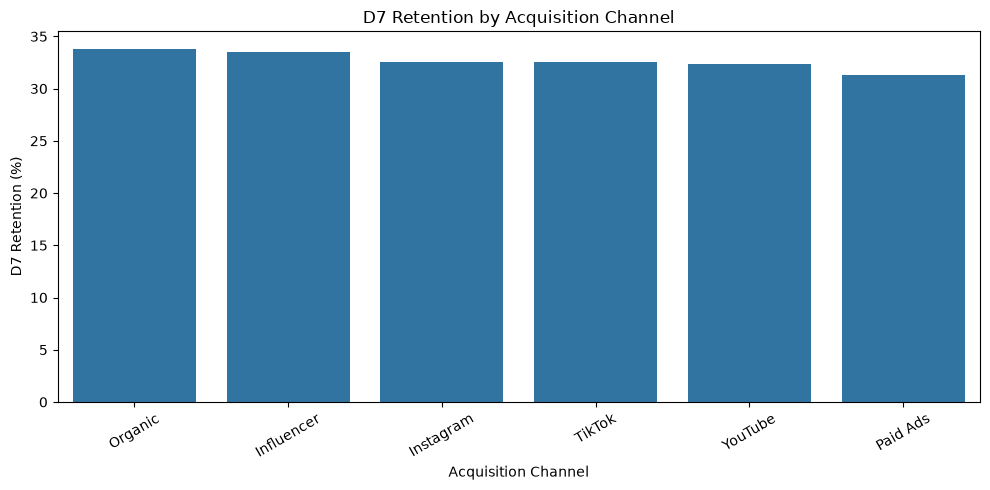

In [6]:
channel_retention = (
    df.groupby("acquisition_channel")["day_7_retained"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=channel_retention.index,
    y=channel_retention.values
)

plt.xticks(rotation=30)

plt.title("D7 Retention by Acquisition Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("D7 Retention (%)")

plt.tight_layout()
plt.show()

## Platform Performance

Compare D7 retention across platforms to determine whether platform is a major retention differentiator.

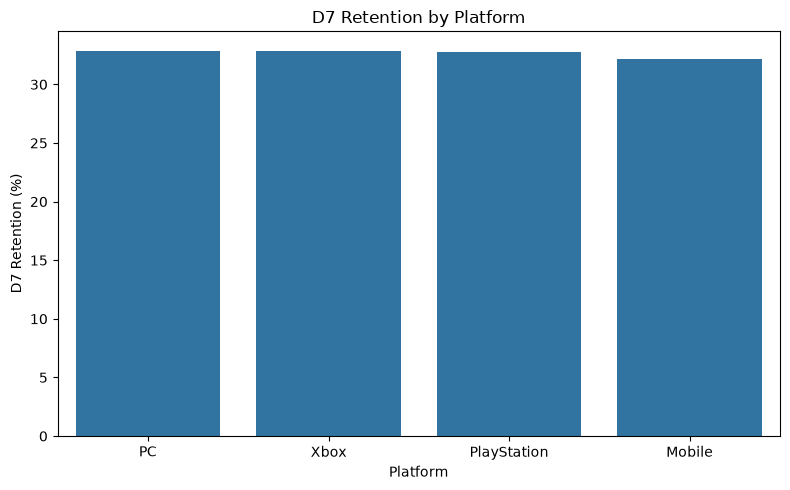

In [7]:
platform_retention = (
    df.groupby("platform")["day_7_retained"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=platform_retention.index,
    y=platform_retention.values
)

plt.title("D7 Retention by Platform")
plt.xlabel("Platform")
plt.ylabel("D7 Retention (%)")

plt.tight_layout()
plt.show()

## Week 1 Player Journey — A/B Experiment

The experiment evaluates whether the proposed Week 1 Player Journey improves D7 retention.

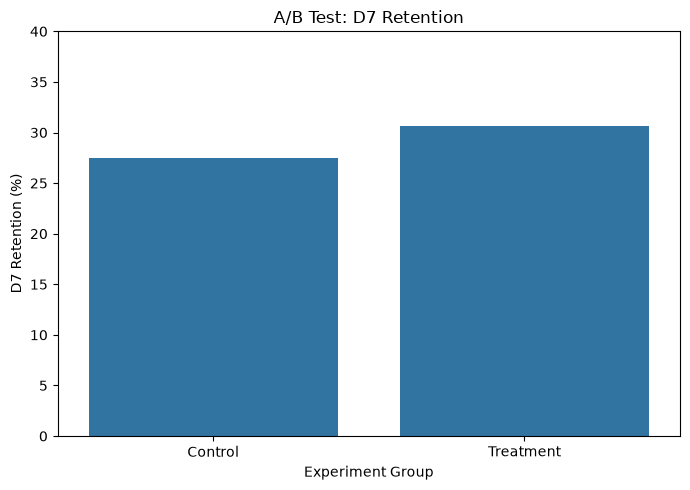

In [8]:
ab_test = pd.DataFrame({
    "Experiment Group": ["Control", "Treatment"],
    "D7 Retention": [27.52, 30.68]
})

plt.figure(figsize=(7, 5))

sns.barplot(
    data=ab_test,
    x="Experiment Group",
    y="D7 Retention"
)

plt.title("A/B Test: D7 Retention")
plt.ylabel("D7 Retention (%)")
plt.xlabel("Experiment Group")

plt.ylim(0, 40)

plt.tight_layout()
plt.show()

### Experiment Result

**Treatment D7:** 30.68%

**Control D7:** 27.52%

**Absolute Lift:** +3.16 pp

**Relative Lift:** +11.48%

**P-value:** 0.0021

**95% CI:** +1.15 pp to +5.17 pp

**Decision:** Ship with gradual rollout.

In [9]:
# Create experiment segment results

experiment_players = df.sample(
    n=3921 * 2,
    random_state=42
).copy()

experiment_players["experiment_group"] = (
    ["Control"] * 3921 +
    ["Treatment"] * 3921
)

# Recreate the synthetic experiment outcomes
np.random.seed(42)

control_d7 = np.random.random(3921) < 0.2716
treatment_d7 = np.random.random(3921) < 0.3016

experiment_players["experiment_d7_retained"] = np.concatenate([
    control_d7,
    treatment_d7
])

# Create engagement segments
experiment_players["engagement_segment"] = pd.cut(
    experiment_players["sessions_week1"],
    bins=[-1, 3, 10, 20, 35],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

# Calculate segment results
segment_results = (
    experiment_players
    .groupby(
        ["engagement_segment", "experiment_group"],
        observed=True
    )
    .agg(
        players=("player_id", "count"),
        d7_retained=("experiment_d7_retained", "sum"),
        d7_retention=("experiment_d7_retained", "mean")
    )
    .reset_index()
)

segment_results["d7_retention"] = (
    segment_results["d7_retention"] * 100
)

# Create Control vs Treatment table
segment_lift = (
    segment_results
    .pivot(
        index="engagement_segment",
        columns="experiment_group",
        values="d7_retention"
    )
    .reset_index()
)

segment_lift["absolute_lift_pp"] = (
    segment_lift["Treatment"]
    - segment_lift["Control"]
)

segment_lift["relative_lift_pct"] = (
    segment_lift["absolute_lift_pp"]
    / segment_lift["Control"]
    * 100
)

segment_lift

experiment_group,engagement_segment,Control,Treatment,absolute_lift_pp,relative_lift_pct
0,Low,26.769627,34.734240,7.964613,29.752425
1,Moderate,26.955543,30.022962,3.067419,11.379548
2,High,28.709990,28.334956,-0.375034,-1.306284
3,Very High,28.571429,31.486880,2.915452,10.204082


## A/B Test Performance by Engagement Segment

The segment analysis evaluates whether the Week 1 Player Journey performs consistently across different player engagement levels.

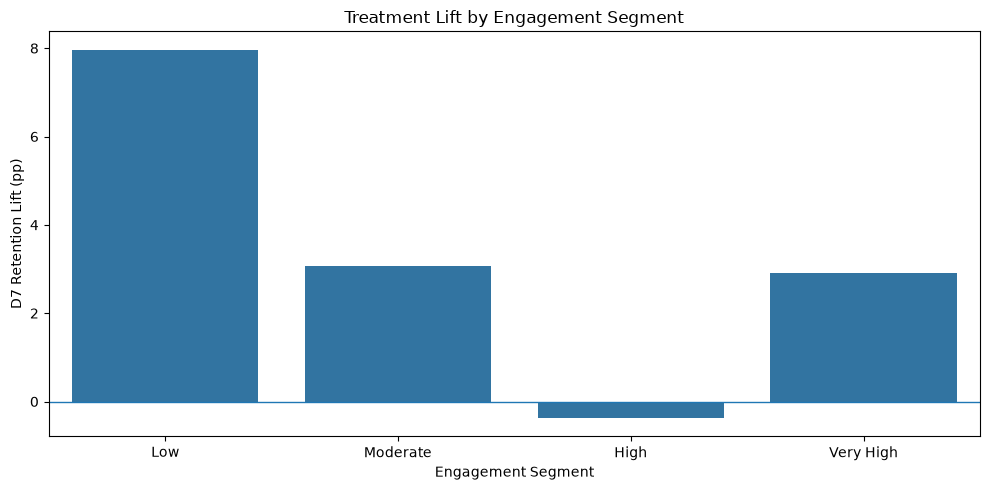

In [10]:
segment_chart = segment_lift.copy()

plt.figure(figsize=(10, 5))

sns.barplot(
    data=segment_chart,
    x="engagement_segment",
    y="absolute_lift_pp"
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Treatment Lift by Engagement Segment")
plt.xlabel("Engagement Segment")
plt.ylabel("D7 Retention Lift (pp)")

plt.tight_layout()
plt.show()

---

# Product Recommendation

### SHIP WITH GRADUAL ROLLOUT

The synthetic experiment shows a statistically significant improvement in D7 retention from **27.52% to 30.68%**.

The strongest statistically supported segment effects were observed among:

- **Low Engagement:** +7.96 pp
- **Moderate Engagement:** +3.06 pp

The initial rollout should therefore prioritize **Low-to-Moderate Engagement new players**, while continuing to monitor the broader population.

### Key Product Loop

**Play → Progress → Reward → New Goal → Return**

### Primary KPI

**D7 Retention**

### Guardrails

- D30 retention
- Crash rate
- Session failures
- Negative player feedback
- Reward abuse
- Core gameplay participation

### Decision

**Proceed with gradual rollout and continued experimentation.**

> All data and experiment results are synthetic and created for portfolio demonstration purposes.

---

## Methodology & Disclaimer

This project uses synthetic player-level data created specifically for portfolio demonstration.

The analysis demonstrates product analytics, experimentation, segmentation, statistical testing, and product decision-making methodology.

The project does not use proprietary EA or EA SPORTS FC telemetry, player data, internal experiments, or confidential information.

Observed relationships in the synthetic dataset should not be interpreted as causal unless supported by the controlled experiment.

All feature concepts are hypothetical product proposals.

In [11]:
import sqlite3
import pandas as pd

# Load your dataset first
df = pd.read_csv("../data/players.csv")

connection = sqlite3.connect("../data/player_analytics.db")

df.to_sql(
    "players",
    connection,
    if_exists="replace",
    index=False
)

print("Player data loaded into SQLite successfully.")

Player data loaded into SQLite successfully.


In [12]:
query = """
SELECT COUNT(*) AS total_players
FROM players;
"""

result = pd.read_sql_query(query, connection)

result

,total_players
0,50000


In [13]:
query = """
SELECT
    COUNT(*) AS total_players,
    SUM(CASE WHEN day_7_retained = 1 THEN 1 ELSE 0 END) AS d7_retained_players,
    ROUND(
        100.0 * SUM(CASE WHEN day_7_retained = 1 THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS d7_retention_pct
FROM players;
"""

result = pd.read_sql_query(query, connection)

result

,total_players,d7_retained_players,d7_retention_pct
0,50000,16342,32.68


In [14]:
query = """
SELECT
    ROUND(
        100.0 * SUM(
            CASE WHEN tutorial_completed = 1 THEN 1 ELSE 0 END
        ) / COUNT(*),
        2
    ) AS tutorial_completion_pct
FROM players;
"""

result = pd.read_sql_query(query, connection)

result

,tutorial_completion_pct
0,75.54


In [15]:
query = """
SELECT
    tutorial_completed,
    COUNT(*) AS players,
    ROUND(
        100.0 * AVG(
            CASE
                WHEN day_7_retained = 1 THEN 1.0
                ELSE 0.0
            END
        ),
        2
    ) AS d7_retention_pct
FROM players
GROUP BY tutorial_completed
ORDER BY tutorial_completed;
"""

result = pd.read_sql_query(query, connection)

result

,tutorial_completed,players,d7_retention_pct
0,0,12229,13.09
1,1,37771,39.03


In [16]:
query = """
SELECT
    first_match_played,
    COUNT(*) AS players,
    ROUND(
        100.0 * AVG(
            CASE
                WHEN day_7_retained = 1 THEN 1.0
                ELSE 0.0
            END
        ),
        2
    ) AS d7_retention_pct
FROM players
GROUP BY first_match_played
ORDER BY first_match_played;
"""

result = pd.read_sql_query(query, connection)

result

,first_match_played,players,d7_retention_pct
0,0,12455,9.91
1,1,37545,40.24


In [17]:
query = """
SELECT
    CASE
        WHEN sessions_week1 BETWEEN 0 AND 3 THEN 'Low'
        WHEN sessions_week1 BETWEEN 4 AND 10 THEN 'Moderate'
        WHEN sessions_week1 BETWEEN 11 AND 20 THEN 'High'
        ELSE 'Very High'
    END AS engagement_segment,

    COUNT(*) AS players,

    ROUND(
        100.0 * AVG(
            CASE
                WHEN day_7_retained = 1 THEN 1.0
                ELSE 0.0
            END
        ),
        2
    ) AS d7_retention_pct

FROM players

GROUP BY engagement_segment

ORDER BY
    CASE engagement_segment
        WHEN 'Low' THEN 1
        WHEN 'Moderate' THEN 2
        WHEN 'High' THEN 3
        WHEN 'Very High' THEN 4
    END;
"""

result = pd.read_sql_query(query, connection)

result

,engagement_segment,players,d7_retention_pct
0,Low,10296,15.75
1,Moderate,22511,27.16
2,High,12885,44.27
3,Very High,4308,67.34


In [18]:
query = """
SELECT
    acquisition_channel,
    COUNT(*) AS players,

    ROUND(
        100.0 * AVG(
            CASE
                WHEN day_7_retained = 1 THEN 1.0
                ELSE 0.0
            END
        ),
        2
    ) AS d7_retention_pct,

    ROUND(
        100.0 * AVG(
            CASE
                WHEN churned = 1 THEN 1.0 ELSE 0.0
            END
        ),
        2
    ) AS churn_rate_pct,

    ROUND(AVG(sessions_week1), 2) AS avg_sessions,

    ROUND(AVG(matches_week1), 2) AS avg_matches

FROM players

GROUP BY acquisition_channel

ORDER BY d7_retention_pct DESC;
"""

result = pd.read_sql_query(query, connection)

result

,acquisition_channel,players,d7_retention_pct,churn_rate_pct,avg_sessions,avg_matches
0,Organic,12431,33.79,69.45,9.78,11.58
1,Influencer,5055,33.51,71.04,9.77,11.42
2,Instagram,7518,32.59,72.36,9.53,10.88
3,TikTok,7512,32.51,70.31,9.81,11.08
4,YouTube,7483,32.37,71.07,9.76,11.11
5,Paid Ads,10001,31.33,72.02,9.81,10.71


In [19]:
query = """
SELECT
    COUNT(*) AS moderate_players,

    ROUND(
        100.0 * COUNT(*) /
        (SELECT COUNT(*) FROM players),
        2
    ) AS player_share_pct,

    ROUND(
        100.0 * AVG(
            CASE
                WHEN day_7_retained = 1 THEN 1.0
                ELSE 0.0
            END
        ),
        2
    ) AS d7_retention_pct,

    ROUND(AVG(sessions_week1), 2) AS avg_sessions,

    ROUND(AVG(matches_week1), 2) AS avg_matches,

    ROUND(AVG(progression_level), 2) AS avg_progression,

    ROUND(AVG(rewards_claimed), 2) AS avg_rewards

FROM players

WHERE sessions_week1 BETWEEN 4 AND 10;
"""

result = pd.read_sql_query(query, connection)

result

,moderate_players,player_share_pct,d7_retention_pct,avg_sessions,avg_matches,avg_progression,avg_rewards
0,22511,45.02,27.16,7.0,7.88,8.37,3.04
